# GFP DMS brightness — distributions & bright/dim threshold

Visualizes the per-scaffold log-brightness distributions for both DMS datasets and shows how the
bright/dim cut is placed and how sensitive the classification is to it.

- **Data:** `DMS_data/avgfp_dms_sequences.csv` (avGFP; column `logMedianBrightness`) and
  `DMS_data/ortho_gfp_dms_sequences.csv` (amacGFP / cgreGFP / ppluGFP; column `logBrightness`).
- **Threshold:** the KDE **antimode** (lowest-density valley between the dead-floor pile and the
  functional mode), computed per scaffold by `brightness_threshold.log_brightness_threshold` — the
  same rule the transform pipelines use to write `brightnessClass`.
- Two alternatives are shown for comparison: the **2-component GMM crossover** (bright = near-WT
  sharp peak only) and the **midpoint of the two modes**.

In [1]:
import csv, os, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.mixture import GaussianMixture
try:
    import arcadia_pycolor as apc; apc.mpl.setup(); HAVE_APC = True
except Exception:
    HAVE_APC = False

sys.path.insert(0, os.path.abspath("."))          # this notebook's dir (avGFP_DMS/)
from brightness_threshold import classify, log_brightness_threshold

FS = 12
plt.rcParams.update({"font.size": FS, "axes.titlesize": FS, "axes.labelsize": FS,
                     "xtick.labelsize": FS, "ytick.labelsize": FS, "legend.fontsize": 8})

DMS = "DMS_data"
# (dataset tag, csv path, log-brightness column) -- rows carry a `scaffold` column
SOURCES = [("avGFP-Sarkisyan", os.path.join(DMS, "avgfp_dms_sequences.csv"), "logMedianBrightness"),
           ("ortho-Somermeyer", os.path.join(DMS, "ortho_gfp_dms_sequences.csv"), "logBrightness")]

def load_scaffolds():
    """Return {scaffold: log10-brightness array} pooled across both DMS tables."""
    d = {}
    for tag, path, col in SOURCES:
        if not os.path.exists(path):
            print(f"missing {path} -- run the transform script first"); continue
        for r in csv.DictReader(open(path)):
            d.setdefault(r["scaffold"], []).append(float(r[col]))
    return {k: np.asarray(v, float) for k, v in d.items()}

DATA = load_scaffolds()
ORDER = [s for s in ["avGFP", "amacGFP", "cgreGFP", "ppluGFP"] if s in DATA] + \
        [s for s in DATA if s not in ("avGFP", "amacGFP", "cgreGFP", "ppluGFP")]

CLS_C = {"dim": "#c5474b", "bright": "#3b8a6e"}
THR_C = {"antimode": "#111111", "gmm-crossover": "#2b6c8f", "mode-midpoint": "#f6a200"}

def gmm_crossover(x):
    """Decision boundary of a 2-component Gaussian mixture (posterior 0.5)."""
    g = GaussianMixture(2, n_init=5, random_state=0).fit(x.reshape(-1, 1))
    xs = np.linspace(x.min(), x.max(), 4000); lab = g.predict(xs.reshape(-1, 1))
    ch = xs[np.where(np.diff(lab) != 0)[0]]; mu = np.sort(g.means_.ravel())
    return float(ch[np.argmin(np.abs(ch - mu.mean()))]) if len(ch) else float(mu.mean())

def candidate_thresholds(x):
    """The pipeline threshold (antimode) + two alternatives, with KDE info."""
    thr, info = log_brightness_threshold(x)
    modes = info.get("modes") or [float(np.median(x))]
    return {"antimode": thr, "gmm-crossover": gmm_crossover(x),
            "mode-midpoint": float(np.mean(modes))}, info

print("scaffolds:", {s: len(DATA[s]) for s in ORDER})

scaffolds: {'avGFP': 51715, 'amacGFP': 33511, 'cgreGFP': 24516, 'ppluGFP': 31402}


## Distributions with the bright/dim split

Each panel shows one scaffold's log-brightness: the histogram is coloured by the **antimode**
classification (red = dim, green = bright), the black curve is the KDE, and the three vertical lines
mark the candidate thresholds. Note how the dead-floor pile and functional mode sit at
scaffold-specific brightness values.

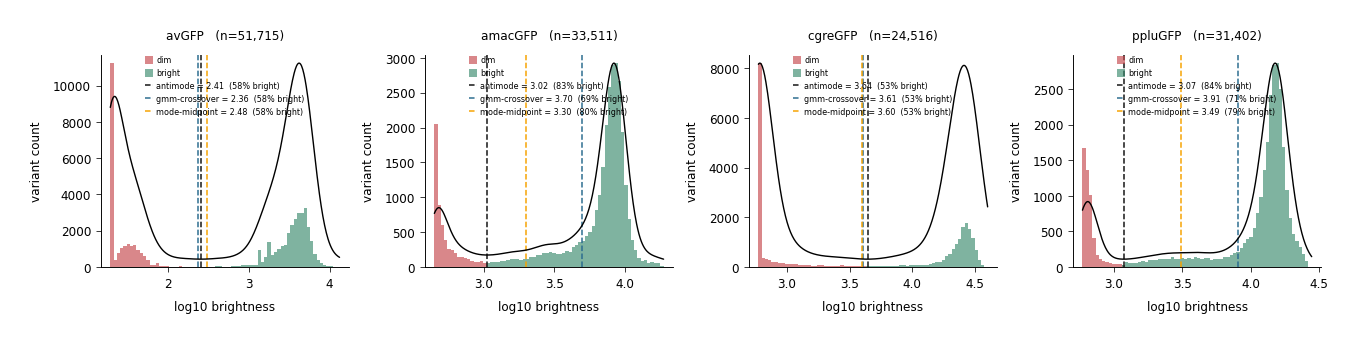

In [2]:
def plot_distributions(bins=70):
    n = len(ORDER)
    fig, axes = plt.subplots(1, n, figsize=(4.6 * n, 4.3), squeeze=False)
    for ax, s in zip(axes[0], ORDER):
        x = DATA[s]; thr, info = candidate_thresholds(x); t = thr["antimode"]
        edges = np.linspace(x.min(), x.max(), bins + 1)
        ax.hist(x[x < t], bins=edges, color=CLS_C["dim"], alpha=0.65, label="dim")
        ax.hist(x[x >= t], bins=edges, color=CLS_C["bright"], alpha=0.65, label="bright")
        xs = np.linspace(x.min(), x.max(), 400)
        ax2 = ax.twinx(); ax2.plot(xs, gaussian_kde(x)(xs), color="k", lw=1.4); ax2.set_yticks([])
        for name, tv in thr.items():
            ax.axvline(tv, color=THR_C[name], ls="--", lw=1.5,
                       label=f"{name} = {tv:.2f}  ({(x >= tv).mean()*100:.0f}% bright)")
        ax.set_title(f"{s}   (n={len(x):,})")
        ax.set_xlabel("log10 brightness"); ax.set_ylabel("variant count")
        ax.legend(loc="upper center", fontsize=8)
    plt.tight_layout(); plt.show()

plot_distributions()

## How the threshold affects the classification

Left axis: the fraction of variants labelled **bright** as the cut sweeps across the brightness range
(the classification "dose-response"). A **flat region** means the split is insensitive to the exact
cut (well-separated modes); a **steep region** means small threshold moves swing many variants. The
markers show where each candidate threshold lands.

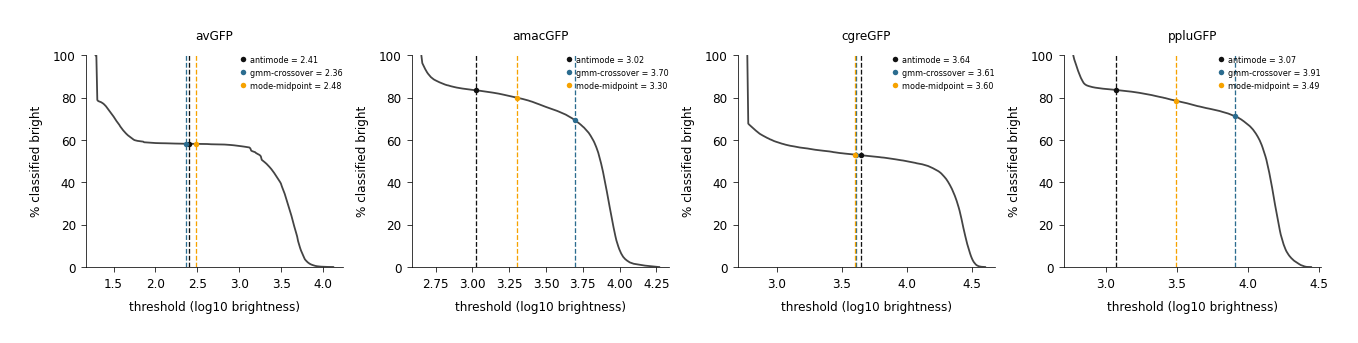

In [3]:
def plot_threshold_effect(steps=250):
    n = len(ORDER)
    fig, axes = plt.subplots(1, n, figsize=(4.6 * n, 4.3), squeeze=False)
    for ax, s in zip(axes[0], ORDER):
        x = DATA[s]; thr, _ = candidate_thresholds(x)
        grid = np.linspace(x.min(), x.max(), steps)
        bright_pct = [(x >= t).mean() * 100 for t in grid]
        ax.plot(grid, bright_pct, color="#444", lw=1.8)
        for name, tv in thr.items():
            ax.axvline(tv, color=THR_C[name], ls="--", lw=1.3)
            ax.scatter([tv], [(x >= tv).mean() * 100], color=THR_C[name], zorder=5, s=30,
                       label=f"{name} = {tv:.2f}")
        ax.set_title(s); ax.set_ylim(0, 100)
        ax.set_xlabel("threshold (log10 brightness)"); ax.set_ylabel("% classified bright")
        ax.legend(loc="upper right", fontsize=8)
    plt.tight_layout(); plt.show()

plot_threshold_effect()

## Summary table

Threshold value and resulting bright/dim split for each scaffold under each method. The
`antimode` rows are what the pipelines actually wrote to `brightnessClass`; a consistency check
against the stored labels is included.

In [4]:
rows = []
for s in ORDER:
    x = DATA[s]; thr, info = candidate_thresholds(x)
    for name, tv in thr.items():
        b = (x >= tv).mean() * 100
        rows.append(dict(scaffold=s, method=name, threshold=round(tv, 3),
                         n=len(x), bright_pct=round(b, 1), dim_pct=round(100 - b, 1),
                         kde_modes=info.get("modes")))
summary = pd.DataFrame(rows)

# consistency: the stored brightnessClass must match recomputing at the antimode
def stored_bright_pct():
    out = {}
    for tag, path, col in SOURCES:
        if not os.path.exists(path):
            continue
        for r in csv.DictReader(open(path)):
            d = out.setdefault(r["scaffold"], [0, 0]); d[0] += r["brightnessClass"] == "bright"; d[1] += 1
    return {k: 100 * a / n for k, (a, n) in out.items()}

stored = stored_bright_pct()
chk = summary[summary.method == "antimode"].assign(
    stored_bright_pct=lambda d: d.scaffold.map(lambda s: round(stored.get(s, float("nan")), 1)))
print("antimode vs stored brightnessClass (should match):")
print(chk[["scaffold", "bright_pct", "stored_bright_pct"]].to_string(index=False))

summary.pivot(index="scaffold", columns="method", values=["threshold", "bright_pct"])

antimode vs stored brightnessClass (should match):
scaffold  bright_pct  stored_bright_pct
   avGFP        58.2               58.2
 amacGFP        83.5               83.5
 cgreGFP        52.8               52.8
 ppluGFP        83.7               83.7


threshold                             bright_pct                \
method    antimode gmm-crossover mode-midpoint   antimode gmm-crossover   
scaffold                                                                  
amacGFP      3.025         3.696         3.302       83.5          69.3   
avGFP        2.406         2.364         2.480       58.2          58.2   
cgreGFP      3.643         3.610         3.599       52.8          53.0   
ppluGFP      3.072         3.906         3.494       83.7          71.3   

                        
method   mode-midpoint  
scaffold                
amacGFP           80.0  
avGFP             58.2  
cgreGFP           53.1  
ppluGFP           78.5